In [1]:
import matplotlib.pyplot as plt


def plt_init():
    plt.rcParams.update({
        # requires a working LaTeX installation & slower than Matplotlib's mathtext
        "text.usetex": False,
        "font.family": "Helvetica",    # or other sans-serif font like Arial
        # "font.sans-serif": "DejaVu Sans"
    })
    plt.rcParams["mathtext.fontset"] = "custom"
    # change the math font to Helvetica
    plt.rcParams["mathtext.rm"] = "Helvetica"
    # use the dejavusans version \mathcal{}
    plt.rcParams["mathtext.cal"] = "DejaVu Serif Display"

    # save svg with embedded fonts instead of converting text to paths
    plt.rcParams['svg.fonttype'] = 'none'
    plt.rcParams["ps.usedistiller"] = "xpdf"    # for scalable eps file

    # depends on whether you want to adjust the distance between subplots by yourself
    plt.rcParams['figure.constrained_layout.use'] = False
    # You can always add bbox_inches='tight' when save figures

    plt.rcParams['ytick.right'] = True
    plt.rcParams['xtick.top'] = True
    plt.rc('xtick', labelsize=12, direction='in')
    plt.rc('ytick', labelsize=12, direction='in')
    plt.rc('axes', labelsize=14, titlesize=14)
    plt.rc('legend', fontsize=12)

In [2]:
plt_init()

In [3]:
import numpy as np
from pyafv import PhysicalParams, FiniteVoronoiSimulator, visualize_2d

radius = 1.0
N = 100

# Illustration of AFV model

In [52]:
np.random.seed(47)

data = np.load('trichoplax_arch_points_mm.npy')
data = data[-2]
pts = data[np.random.choice(data.shape[0], size=200, replace=False)]
pts *= 8
pts.shape

pts =np.concatenate((pts, np.array([[10,8], [10,7], [8.5, 8.1], [9, 7.9], [10.5, 7.9], [11, 9], [12, 8]])))

<Axes: >

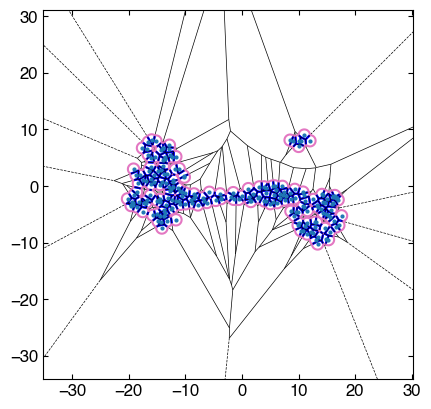

In [53]:
sim = FiniteVoronoiSimulator(pts, PhysicalParams(P0=4.8, Lambda=0.5))
sim.plot_2d()

In [54]:
from tqdm.auto import tqdm

dt = 0.01

for _ in tqdm(range(2000), desc="Relaxing"):
    diag = sim.build()
    pts += diag['forces'] * dt
    sim.update_positions(pts)

Relaxing:   0%|          | 0/2000 [00:00<?, ?it/s]

<Axes: >

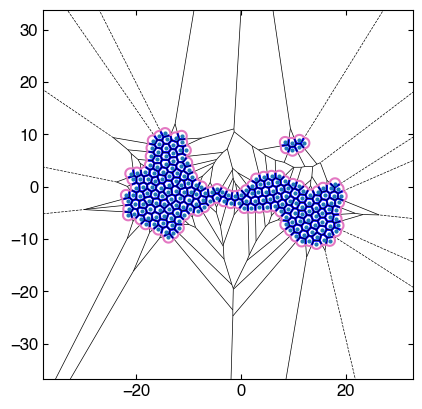

In [55]:
sim.plot_2d()

In [56]:
(vor, vertices_all, ridge_vertices_all, num_vertices,
            vertexpair2ridge, vertex_points) = sim._build_voronoi_with_extensions()

geom, vertices_all = sim._per_cell_geometry(vor, vertices_all, ridge_vertices_all, num_vertices, vertexpair2ridge)

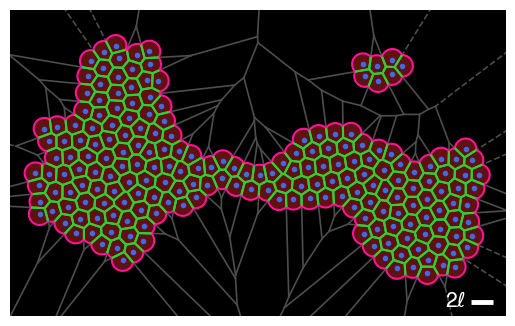

In [64]:
fig, ax = plt.subplots(dpi=100)



box_size = 15
r = radius
center = np.mean(pts, axis=0)
if N > 1:
    span_x = np.ptp(pts[:, 0])  # pts span in x
    span_y = np.ptp(pts[:, 1])  # pts span in y
    L = max(span_x, span_y) + 3.0 * r
    L *= 0.8
else:
    L = 5.0 * r

gray_color = 0.3 * np.ones(3)
# Draw Voronoi ridge segments
for idx in range(len(vor.ridge_vertices)):
    x1, y1 = vertices_all[ridge_vertices_all[idx][0]]
    x2, y2 = vertices_all[ridge_vertices_all[idx][1]]
    if -1 not in vor.ridge_vertices[idx]:
        ax.plot([x1, x2], [y1, y2], '-', lw=1.2, color=gray_color, zorder=-1)
    else:
        ax.plot([x1, x2], [y1, y2], '--', lw=1.2, color=gray_color, zorder=-1)

visualize_2d(pts, diag, r=radius, ax=ax,
             cell_colors='C3', fill_alpha=0.45, 
             show_points=True, point_colors='royalblue', point_size=3**2, 
             straight_lw=1.5, straight_colors='limegreen',
             arc_lw=1.5, arc_colors='deeppink')

ax.tick_params(axis='both', length=0, labelbottom=False, labelleft=False)

bar_left = center[0]+box_size + 7.
bar_y = center[1]-box_size+2.9
ax.plot([bar_left-r, bar_left+r], [bar_y, bar_y], 'w-', lw=3.5, solid_capstyle='butt')   # <-- no rounded extension
ax.text(bar_left-3.5, bar_y-0.4, r'$2\ell$', color='w', fontsize=15)

for spine in ax.spines.values():
    spine.set_linewidth(0.0) # spine.set_linewidth(1.2)   # choose your thickness

ax.set_xlim(center[0]-box_size-6.8, center[0]+box_size+9.2)
ax.set_ylim(center[1]-box_size+1.6, center[1]+box_size)

ax.set_facecolor("black")

plt.savefig('FV_model.svg', dpi=300, bbox_inches='tight')

plt.show()